# Analyse der Verfügbarkeitsdynamik

Dieses Notebook untersucht die beobachteten Veränderungen der Verfügbarkeit von Produktvarianten bei **Tennistown** und **Tennis-Heine** im Erhebungszeitraum vom 14.06.2026 bis zum 17.07.2026.

Im Mittelpunkt stehen:

- die Verteilung der beobachteten Verfügbarkeitszustände
- der Umfang und die Richtung der Verfügbarkeitswechsel
- mögliche Unterschiede zwischen den Produktkategorien
- ausgewählte Produktvarianten mit besonders häufigen Verfügbarkeitswechseln
- eine explorative Fallbetrachtung der öffentlich mit den Wimbledon-Halbfinalisten verbundenen Schlägermodelle

Die Analyse wird bewusst auf wenige aggregierte Kennzahlen und ausgewählte Fallbeispiele begrenzt.

Tennis-Point wird nicht in die zeitliche Verfügbarkeitsanalyse einbezogen. Aufgrund der in `01_data_quality` dokumentierten vollständig und teilweise unvollständigen Abrufe kann bei fehlenden Tennis-Point-Produktbeobachtungen nicht unterschieden werden, ob eine Produktvariante tatsächlich nicht verfügbar war oder lediglich technisch nicht erfasst wurde. Eine Einbeziehung könnte daher zu einer verzerrten Interpretation der Verfügbarkeitsentwicklung führen.

Produktvarianten werden innerhalb eines Händlers über die Kombination aus `product_url_key` und `reference_variant` verfolgt. Eine normalisierte GTIN ist für diese händlerinterne Analyse nicht erforderlich.

> **Hinweis zur Interpretation:** Die Variable `availability` beschreibt ausschließlich den zum jeweiligen Abruf auf der Produktseite erfassten Verfügbarkeitsstatus. Ein Wechsel von `in_stock` zu `out_of_stock` kann auf einen Abverkauf hindeuten, belegt jedoch weder eine konkrete Verkaufsmenge noch die zugrunde liegende Ursache. Ebenso kann ein Wechsel zurück zu `in_stock` beispielsweise durch eine Nachlieferung oder eine erneute Aktivierung des Angebots entstehen.
>
> Fehlende Produktbeobachtungen werden nicht ergänzt und nicht als `out_of_stock` interpretiert. Verfügbarkeitswechsel werden später ausschließlich zwischen unmittelbar aufeinanderfolgenden geplanten Abrufen bestimmt.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Einheitliches Erscheinungsbild für alle Visualisierungen festlegen
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
# --- PFAD-KONFIGURATION ---

# Verzeichnis mit dem aufbereiteten Datenbestand
data_processed_dir = '../data/processed'

# Dateiname der aufbereiteten Datentabelle
processed_file_name = 'tennis_data_prepared.csv'

# Vollständigen Dateipfad erzeugen
processed_file_path = os.path.join(data_processed_dir, processed_file_name)

## Aufbereiteten Datenbestand einlesen

Die in `02_data_preparation` erzeugte Datei `tennis_data_prepared.csv` wird als Grundlage der Verfügbarkeitsanalyse eingelesen.

Die Identifikatoren `product_url_key`, `ean` und `gtin_normalized` werden als Zeichenfolgen geladen. `timestamp` und `run_date` werden als Datumswerte eingelesen, damit die Produktbeobachtungen später chronologisch ausgewertet werden können.

In [3]:
if not os.path.exists(processed_file_path):
    raise FileNotFoundError(f'Die Datei "{processed_file_path}" wurde nicht gefunden.')

df_tennis_data = pd.read_csv(
    processed_file_path,
    encoding='utf-8',
    dtype={
        'product_url_key': 'string',
        'ean': 'string',
        'gtin_normalized': 'string'
    },
    parse_dates=[
        'timestamp',
        'run_date'
    ]
)

print('--- AUFBEREITETER DATENBESTAND EINGELESEN ---')
print(f'Beobachtungen: {len(df_tennis_data)}')
print(f'Spalten: {len(df_tennis_data.columns)}')
print(f'Erhebungszeitraum: {df_tennis_data["timestamp"].min():%d.%m.%Y} bis {df_tennis_data["timestamp"].max():%d.%m.%Y}')

--- AUFBEREITETER DATENBESTAND EINGELESEN ---
Beobachtungen: 87609
Spalten: 19
Erhebungszeitraum: 14.06.2026 bis 17.07.2026


## Umfang der Datenbasis

Für die weitere Analyse werden ausschließlich die Beobachtungen von Tennistown und Tennis-Heine berücksichtigt. Der Umfang der Datenbasis wird anhand der Anzahl der Produktbeobachtungen, unterschiedlichen Produktvarianten und beobachteten Verfügbarkeitszustände zusammengefasst.

Die ausgewiesenen Verfügbarkeitsanteile beziehen sich auf einzelne Produktbeobachtungen. Wiederholte Beobachtungen derselben Produktvariante über mehrere Abrufe werden daher mehrfach berücksichtigt.

In [4]:
# --- DATENBESTAND DER VERFÜGBARKEITSANALYSE VORBEREITEN ---

# Zu berücksichtigende Händler und ihre Reihenfolge festlegen
retailer_order = ['Tennistown', 'Tennis-Heine']

# Spalten zur händlerinternen Bestimmung einer Produktvariante festlegen
product_variant_columns = ['retailer', 'product_url_key', 'reference_variant']

# Beobachtungen der beiden berücksichtigten Händler auswählen
df_availability_data = df_tennis_data.loc[df_tennis_data['retailer'].isin(retailer_order)].copy()

# Anzahl unterschiedlicher Produktvarianten je Händler bestimmen
df_unique_product_variants = (
    df_availability_data[product_variant_columns]
    .drop_duplicates()
    .groupby('retailer')
    .size()
)

# --- UMFANG DER VERFÜGBARKEITSDATEN ZUSAMMENFASSEN ---

df_availability_data_overview = (
    df_availability_data
    .groupby('retailer', sort=False)
    .agg(
        Observations=('availability', 'size'),
        In_stock=('availability', lambda values: values.eq('in_stock').sum()),
        Out_of_stock=('availability', lambda values: values.eq('out_of_stock').sum())
    )
    .reset_index()
    .rename(columns={'retailer': 'Retailer', 'In_stock': 'In stock', 'Out_of_stock': 'Out of stock'})
)

# Anzahl unterschiedlicher Produktvarianten ergänzen
df_availability_data_overview['Product variants'] = df_availability_data_overview['Retailer'].map(df_unique_product_variants)

# Anteil der verfügbaren und nicht verfügbaren Beobachtungen berechnen
df_availability_data_overview['In stock (%)'] = (
    df_availability_data_overview['In stock'] / df_availability_data_overview['Observations']
    * 100
).round(1)

df_availability_data_overview['Out of stock (%)'] = (
    df_availability_data_overview['Out of stock'] / df_availability_data_overview['Observations']
    * 100
).round(1)

# Gewünschte Spaltenreihenfolge festlegen
df_availability_data_overview = df_availability_data_overview[[
    'Retailer',
    'Observations',
    'Product variants',
    'In stock',
    'In stock (%)',
    'Out of stock',
    'Out of stock (%)'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_availability_data_overview = (
    df_availability_data_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- UMFANG DER VERFÜGBARKEITSDATEN ---')
print('Zeigt Produktbeobachtungen, Produktvarianten und Verfügbarkeitszustände je Händler an.\n')

display(df_availability_data_overview)

--- UMFANG DER VERFÜGBARKEITSDATEN ---
Zeigt Produktbeobachtungen, Produktvarianten und Verfügbarkeitszustände je Händler an.



,Retailer,Observations,Product variants,In stock,In stock (%),Out of stock,Out of stock (%)
0,Tennistown,39394,723,23334,59.2,16060,40.8
1,Tennis-Heine,27458,491,16388,59.7,11070,40.3


Für Tennistown stehen 39.394 Beobachtungen zu 723 Produktvarianten zur Verfügung. In 59,2 % dieser Beobachtungen wird die jeweilige Produktvariante als `in_stock` und in 40,8 % als `out_of_stock` erfasst.

Bei Tennis-Heine entfallen 27.458 Beobachtungen auf 491 Produktvarianten. Der Anteil verfügbarer Beobachtungen liegt bei 59,7 %, während 40,3 % als `out_of_stock` erfasst werden. Die Verteilung der beobachteten Verfügbarkeitszustände fällt damit bei beiden Händlern nahezu identisch aus.

## Vergleichbare Verfügbarkeitsbeobachtungen bilden

Zur Untersuchung von Verfügbarkeitswechseln wird der Status einer Produktvariante mit dem Status ihrer unmittelbar vorhergehenden Beobachtung beim gleichen Händler verglichen.

Hierfür werden ausschließlich Beobachtungen aus direkt aufeinanderfolgenden geplanten Abrufen verwendet:

- der Vergleich zwischen `run1` und `run2` desselben Abruftages
- der Vergleich zwischen `run2` eines Abruftages und `run1` des unmittelbar folgenden Tages

Fehlt eine der erforderlichen Beobachtungen, wird kein Vergleichspaar gebildet. Dadurch werden Erfassungslücken nicht als Verfügbarkeitswechsel interpretiert. Ein Wechsel von `in_stock` zu `out_of_stock` beziehungsweise von `out_of_stock` zu `in_stock` wird nur dann gezählt, wenn beide Zustände tatsächlich in unmittelbar aufeinanderfolgenden geplanten Abrufen beobachtet wurden.

In [5]:
# --- VERFÜGBARKEITSBEOBACHTUNGEN CHRONOLOGISCH VORBEREITEN ---

# Kopie des analyserelevanten Datenbestands erstellen
df_availability_history = df_availability_data.copy()

# Reihenfolge der beiden täglichen Abrufe festlegen
df_availability_history['run_order'] = df_availability_history['run'].map({'run1': 1, 'run2': 2})

# Beobachtungen jeder Produktvariante nach den geplanten Abrufen ordnen
df_availability_history = (
    df_availability_history
    .sort_values(product_variant_columns + ['run_date', 'run_order'])
    .reset_index(drop=True)
)

# Gruppierung für Vergleiche innerhalb derselben Produktvariante vorbereiten
availability_history_groups = df_availability_history.groupby(product_variant_columns, sort=False)

# Verfügbarkeitsstatus und Abrufinformationen der jeweils vorherigen Beobachtung ergänzen
df_availability_history['previous_availability'] = availability_history_groups['availability'].shift(1)
df_availability_history['previous_run_date'] = availability_history_groups['run_date'].shift(1)
df_availability_history['previous_run'] = availability_history_groups['run'].shift(1)

In [6]:
# --- UNMITTELBAR VERGLEICHBARE VERFÜGBARKEITSBEOBACHTUNGEN BESTIMMEN ---

# Vergleich von run1 und run2 desselben Abruftages kennzeichnen
is_same_day_pair = (
    df_availability_history['previous_run'].eq('run1')
    & df_availability_history['run'].eq('run2')
    & df_availability_history['previous_run_date'].eq(df_availability_history['run_date'])
)

# Vergleich von run2 und run1 des unmittelbar folgenden Tages kennzeichnen
is_next_day_pair = (
    df_availability_history['previous_run'].eq('run2')
    & df_availability_history['run'].eq('run1')
    & df_availability_history['run_date'].eq(df_availability_history['previous_run_date'] + pd.Timedelta(days=1))
)

# Art des zeitlichen Vergleichs festhalten
df_availability_history['comparison_interval'] = pd.NA

df_availability_history.loc[is_same_day_pair, 'comparison_interval'] = 'run1 to run2'
df_availability_history.loc[is_next_day_pair, 'comparison_interval'] = 'run2 to next run1'

# Nur unmittelbar vergleichbare Beobachtungspaare übernehmen
comparable_pair_mask = is_same_day_pair | is_next_day_pair

df_availability_pairs = (
    df_availability_history
    .loc[comparable_pair_mask]
    .copy()
    .reset_index(drop=True)
)

In [7]:
# --- VERFÜGBARKEITSWECHSEL BESTIMMEN ---

# Beobachtungspaare mit verändertem Verfügbarkeitsstatus kennzeichnen
df_availability_pairs['availability_changed'] = df_availability_pairs['availability'].ne(df_availability_pairs['previous_availability'])

# Richtung des beobachteten Verfügbarkeitsübergangs festhalten
df_availability_pairs['availability_transition'] = df_availability_pairs['previous_availability'] + ' to ' + df_availability_pairs['availability']

In [8]:
# --- VERFÜGBARKEITSWECHSEL JE HÄNDLER ZUSAMMENFASSEN ---
df_availability_change_overview = (
    df_availability_pairs
    .groupby('retailer', sort=False)
    .agg(
        Comparable_pairs=('availability_changed', 'size'),  
        Availability_changes=('availability_changed', 'sum'),
        In_stock_to_out_of_stock=('availability_transition', lambda values: values.eq('in_stock to out_of_stock').sum()),
        Out_of_stock_to_in_stock=('availability_transition', lambda values: values.eq('out_of_stock to in_stock').sum())
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Comparable_pairs': 'Comparable pairs',
        'Availability_changes': 'Availability changes',
        'In_stock_to_out_of_stock': 'In stock to out of stock',
        'Out_of_stock_to_in_stock': 'Out of stock to in stock'
    })
)

# Anteil der Beobachtungspaare mit verändertem Verfügbarkeitsstatus berechnen
df_availability_change_overview['Availability change rate (%)'] = (
    df_availability_change_overview['Availability changes']
    / df_availability_change_overview['Comparable pairs']
    * 100
).round(2)

# Gewünschte Spaltenreihenfolge festlegen
df_availability_change_overview = df_availability_change_overview[[
    'Retailer',
    'Comparable pairs',
    'Availability changes',
    'Availability change rate (%)',
    'In stock to out of stock',
    'Out of stock to in stock'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_availability_change_overview = (
    df_availability_change_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- UMFANG DER BEOBACHTETEN VERFÜGBARKEITSWECHSEL ---')
print('Zeigt vergleichbare Beobachtungspaare und festgestellte Verfügbarkeitswechsel je Händler an.\n')

display(df_availability_change_overview)

--- UMFANG DER BEOBACHTETEN VERFÜGBARKEITSWECHSEL ---
Zeigt vergleichbare Beobachtungspaare und festgestellte Verfügbarkeitswechsel je Händler an.



,Retailer,Comparable pairs,Availability changes,Availability change rate (%),In stock to out of stock,Out of stock to in stock
0,Tennistown,33144,91,0.27,58,33
1,Tennis-Heine,23119,75,0.32,42,33


Bei Tennistown werden 33.144 unmittelbar vergleichbare Beobachtungspaare gebildet. In 91 Fällen verändert sich der Verfügbarkeitsstatus, was einer Wechselrate von 0,27 % entspricht. Dabei werden 58 Wechsel von `in_stock` zu `out_of_stock` und 33 Wechsel in die entgegengesetzte Richtung beobachtet.

Bei Tennis-Heine treten innerhalb von 23.119 vergleichbaren Beobachtungspaaren 75 Verfügbarkeitswechsel auf. Die Wechselrate liegt mit 0,32 % ebenfalls auf einem sehr niedrigen Niveau. Von den beobachteten Wechseln entfallen 42 auf den Übergang von `in_stock` zu `out_of_stock` und 33 auf den Übergang von `out_of_stock` zu `in_stock`.

Obwohl bei beiden Händlern rund 40 % aller Produktbeobachtungen als `out_of_stock` erfasst werden, wechseln die einzelnen Produktvarianten nur selten zwischen den beiden Zuständen. Die Verfügbarkeitszustände bleiben über unmittelbar aufeinanderfolgende Abrufe somit überwiegend stabil. Bei beiden Händlern werden etwas häufiger Wechsel zur Nichtverfügbarkeit als zur Verfügbarkeit beobachtet. Daraus kann jedoch weder auf konkrete Abverkäufe noch auf Nachlieferungen geschlossen werden.

Die Übersicht zählt einzelne Übergänge. Eine Produktvariante kann daher mehrfach als Verfügbarkeitswechsel berücksichtigt werden. Wie viele unterschiedliche Produktvarianten mindestens einmal ihren Status verändern, wird im folgenden Abschnitt untersucht.

## Produktvarianten mit Verfügbarkeitswechseln bestimmen

Die bisherige Übersicht betrachtet jeden Übergang zwischen zwei unmittelbar aufeinanderfolgenden Verfügbarkeitsbeobachtungen separat. Eine Produktvariante kann daher mehrfach als Verfügbarkeitswechsel berücksichtigt werden, wenn ihr Status im Erhebungszeitraum wiederholt zwischen `in_stock` und `out_of_stock` wechselt.

Im folgenden Schritt wird jede Produktvariante nur einmal betrachtet. Die Ergebnistabelle zeigt zunächst, für wie viele der vorhandenen Produktvarianten mindestens ein unmittelbar vergleichbares Beobachtungspaar vorliegt. Anschließend wird bestimmt, bei wie vielen dieser vergleichbaren Produktvarianten mindestens ein Verfügbarkeitswechsel festgestellt wird.

In [9]:
# --- VERFÜGBARKEITSWECHSEL JE PRODUKTVARIANTE ZUSAMMENFASSEN ---
df_product_variant_availability_summary = (
    df_availability_pairs
    .groupby(product_variant_columns, sort=False)
    .agg(Has_availability_change=('availability_changed', 'any'))       # Kennzeichnen, ob bei der Produktvariante mindestens ein Verfügbarkeitswechsel vorliegt
    .reset_index()
)

# --- BETROFFENE PRODUKTVARIANTEN JE HÄNDLER ZUSAMMENFASSEN ---
df_affected_availability_product_variants = (
    df_product_variant_availability_summary
    .groupby('retailer', sort=False)
    .agg(
        Comparable_product_variants=('Has_availability_change', 'size'),                # Alle Produktvarianten mit mindestens einem Vergleichspaar zählen
        Product_variants_with_availability_change=('Has_availability_change', 'sum')    # Produktvarianten mit mindestens einem Verfügbarkeitswechsel zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Comparable_product_variants': 'Comparable product variants',
        'Product_variants_with_availability_change': 'Product variants with availability change'
    })
)

# Gesamtzahl aller vorhandenen Produktvarianten ergänzen
df_affected_availability_product_variants['Product variants'] = df_affected_availability_product_variants['Retailer'].map(df_unique_product_variants)

# Anteil der Produktvarianten mit mindestens einem Vergleichspaar berechnen
df_affected_availability_product_variants['Comparable product variants (%)'] = (
    df_affected_availability_product_variants['Comparable product variants']
    / df_affected_availability_product_variants['Product variants']
    * 100
).round(1)

# Anteil der vergleichbaren Produktvarianten mit mindestens einem Verfügbarkeitswechsel berechnen
df_affected_availability_product_variants['Affected product variants (%)'] = (
    df_affected_availability_product_variants['Product variants with availability change']
    / df_affected_availability_product_variants['Comparable product variants']
    * 100
).round(1)

# Gewünschte Spaltenreihenfolge festlegen
df_affected_availability_product_variants = df_affected_availability_product_variants[[
    'Retailer',
    'Product variants',
    'Comparable product variants',
    'Comparable product variants (%)',
    'Product variants with availability change',
    'Affected product variants (%)'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_affected_availability_product_variants = (
    df_affected_availability_product_variants
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- PRODUKTVARIANTEN MIT VERFÜGBARKEITSWECHSELN ---')
print('Zeigt den Anteil vergleichbarer und von Verfügbarkeitswechseln betroffener Produktvarianten je Händler an.\n')

display(df_affected_availability_product_variants)

--- PRODUKTVARIANTEN MIT VERFÜGBARKEITSWECHSELN ---
Zeigt den Anteil vergleichbarer und von Verfügbarkeitswechseln betroffener Produktvarianten je Händler an.



,Retailer,Product variants,Comparable product variants,Comparable product variants (%),Product variants with availability change,Affected product variants (%)
0,Tennistown,723,721,99.7,65,9.0
1,Tennis-Heine,491,491,100.0,56,11.4


Bei Tennistown liegt für 721 der insgesamt 723 Produktvarianten mindestens ein unmittelbar vergleichbares Beobachtungspaar vor. Dies entspricht einem Anteil von 99,7 %. Bei 65 dieser vergleichbaren Produktvarianten wird im Erhebungszeitraum mindestens ein Verfügbarkeitswechsel festgestellt. Der Anteil betroffener Produktvarianten beträgt damit 9,0 %.

Bei Tennis-Heine können alle 491 Produktvarianten unmittelbar verglichen werden. Bei 56 Varianten und damit bei 11,4 % wird mindestens ein Verfügbarkeitswechsel beobachtet. Der Anteil betroffener Produktvarianten liegt somit geringfügig über dem entsprechenden Anteil bei Tennistown.

Bei beiden Händlern behält der überwiegende Teil der Produktvarianten innerhalb der unmittelbar vergleichbaren Beobachtungspaare seinen Verfügbarkeitsstatus bei. Da die zuvor ermittelte Anzahl einzelner Verfügbarkeitswechsel jeweils über der Anzahl betroffener Produktvarianten liegt, verändern einige Varianten ihren Status im Erhebungszeitraum mehrfach.

Die Ergebnisse zeigen noch nicht, ob sich die Verfügbarkeitsdynamik zwischen Tennisschlägern, Tennisschuhen und Tennissaiten unterscheidet. Dies wird im folgenden Abschnitt untersucht.

## Verfügbarkeitswechsel nach Produktkategorie vergleichen

Die beobachteten Verfügbarkeitswechsel werden ergänzend nach Produktkategorie aufgeschlüsselt. Dadurch wird untersucht, ob sich die Verfügbarkeitsdynamik zwischen Tennisschlägern, Tennisschuhen und Tennissaiten unterscheidet.

Da der Umfang vergleichbarer Beobachtungspaare zwischen den Kategorien unterschiedlich ausfällt, wird neben der absoluten Anzahl der Wechsel insbesondere die Verfügbarkeitswechselrate betrachtet. Sie beschreibt den Anteil unmittelbar vergleichbarer Beobachtungspaare, bei denen sich der Verfügbarkeitsstatus verändert.

In [10]:
# --- VERFÜGBARKEITSWECHSEL NACH PRODUKTKATEGORIE ZUSAMMENFASSEN ---

df_availability_change_category_overview = (
    df_availability_pairs
    .groupby(['retailer', 'category'], sort=False)
    .agg(
        Comparable_pairs=('availability_changed', 'size'),
        Availability_changes=('availability_changed', 'sum'),
        In_stock_to_out_of_stock=('availability_transition', lambda values: values.eq('in_stock to out_of_stock').sum()),
        Out_of_stock_to_in_stock=('availability_transition', lambda values: values.eq('out_of_stock to in_stock').sum())
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'category': 'Category',
        'Comparable_pairs': 'Comparable pairs',
        'Availability_changes': 'Availability changes',
        'In_stock_to_out_of_stock': 'In stock to out of stock',
        'Out_of_stock_to_in_stock': 'Out of stock to in stock'
    })
)

# Anteil der Beobachtungspaare mit verändertem Verfügbarkeitsstatus berechnen
df_availability_change_category_overview['Availability change rate (%)'] = (
    df_availability_change_category_overview['Availability changes']
    / df_availability_change_category_overview['Comparable pairs']
    * 100
).round(2)

# Gewünschte Reihenfolge der Produktkategorien festlegen
category_order = ['rackets', 'shoes', 'strings']

# Händler und Produktkategorien als geordnete Merkmale festlegen
df_availability_change_category_overview['Retailer'] = pd.Categorical(
    df_availability_change_category_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_availability_change_category_overview['Category'] = pd.Categorical(
    df_availability_change_category_overview['Category'],
    categories=category_order,
    ordered=True
)

# Ergebnisse nach Händler und Produktkategorie anordnen
df_availability_change_category_overview = (
    df_availability_change_category_overview
    .sort_values(['Retailer', 'Category'])
    .reset_index(drop=True)
)

# Gewünschte Spaltenreihenfolge festlegen
df_availability_change_category_overview = df_availability_change_category_overview[[
    'Retailer',
    'Category',
    'Comparable pairs',
    'Availability changes',
    'Availability change rate (%)',
    'In stock to out of stock',
    'Out of stock to in stock'
]]

print('--- VERFÜGBARKEITSWECHSEL NACH PRODUKTKATEGORIE ---')
print('Zeigt vergleichbare Beobachtungspaare und Verfügbarkeitswechsel je Händler und Produktkategorie an.\n')

display(df_availability_change_category_overview)

--- VERFÜGBARKEITSWECHSEL NACH PRODUKTKATEGORIE ---
Zeigt vergleichbare Beobachtungspaare und Verfügbarkeitswechsel je Händler und Produktkategorie an.



,Retailer,Category,Comparable pairs,Availability changes,Availability change rate (%),In stock to out of stock,Out of stock to in stock
0,Tennistown,rackets,11588,41,0.35,28,13
1,Tennistown,shoes,17336,30,0.17,21,9
2,Tennistown,strings,4220,20,0.47,9,11
3,Tennis-Heine,rackets,17118,57,0.33,33,24
4,Tennis-Heine,shoes,4129,7,0.17,3,4
5,Tennis-Heine,strings,1872,11,0.59,6,5


Die Verfügbarkeitswechselraten werden anschließend in einem gruppierten Balkendiagramm gegenübergestellt. Dadurch werden Unterschiede zwischen den Produktkategorien und den beiden Händlern unmittelbar sichtbar.

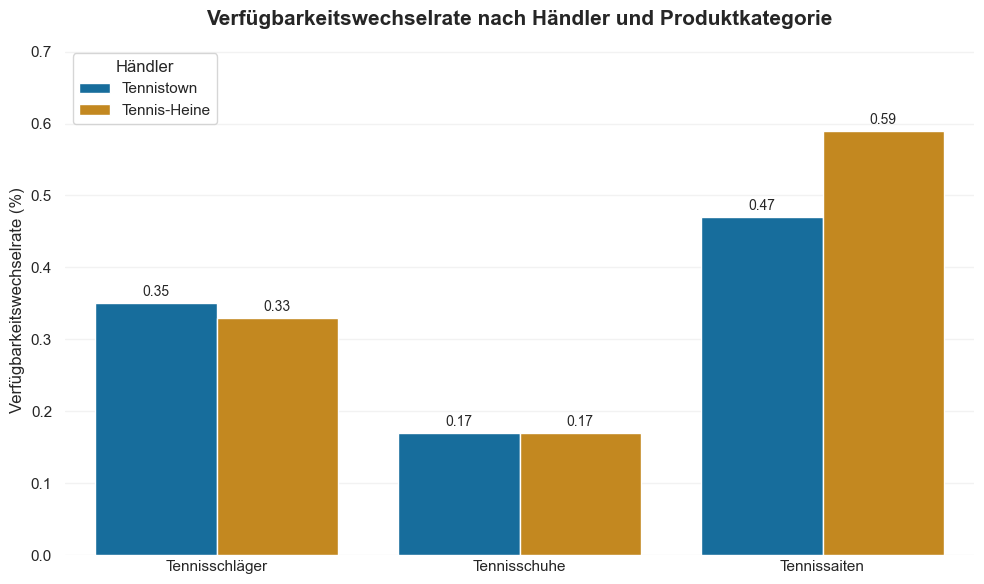

In [11]:
# --- VERFÜGBARKEITSWECHSELRATEN NACH PRODUKTKATEGORIE VISUALISIEREN ---

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Gruppiertes Balkendiagramm erzeugen
sns.barplot(
    data=df_availability_change_category_overview,
    x='Category',
    y='Availability change rate (%)',
    hue='Retailer',
    order=category_order,
    hue_order=retailer_order,
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte oberhalb der Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Deutsche Bezeichnungen der Produktkategorien verwenden
category_labels = {
    'rackets': 'Tennisschläger',
    'shoes': 'Tennisschuhe',
    'strings': 'Tennissaiten'
}

ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([category_labels[category] for category in category_order])

# Diagramm beschriften
ax.set_title('Verfügbarkeitswechselrate nach Händler und Produktkategorie', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Verfügbarkeitswechselrate (%)')

# Achsenmarkierungen unter den Kategorien entfernen
ax.tick_params(axis='x', length=0)

# Legende und Gitternetz anpassen
ax.legend(title='Händler')
ax.grid(axis='y', alpha=0.25)

# Platz für die Beschriftungen oberhalb der Balken schaffen
ax.set_ylim(0, df_availability_change_category_overview['Availability change rate (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Bei beiden Händlern weisen Tennissaiten die höchste Verfügbarkeitswechselrate auf. Sie beträgt bei Tennistown 0,47 % und bei Tennis-Heine 0,59 %. Die vergleichsweise hohen Raten beruhen allerdings auf deutlich weniger Beobachtungspaaren als bei Tennisschlägern und Tennisschuhen.

Bei Tennisschlägern liegen die Wechselraten mit 0,35 % bei Tennistown und 0,33 % bei Tennis-Heine auf einem ähnlichen Niveau. Tennisschuhe weisen bei beiden Händlern mit jeweils rund 0,17 % die geringste Verfügbarkeitsdynamik auf.

Trotz der Unterschiede zwischen den Produktkategorien bleiben die Wechselraten durchgängig unter 1 %. Der Verfügbarkeitsstatus der Produktvarianten ist somit auch innerhalb der einzelnen Kategorien über unmittelbar aufeinanderfolgende Abrufe überwiegend stabil.

## Produktvarianten mit häufigen Verfügbarkeitswechseln betrachten

Anschließend wird untersucht, welche konkreten Produktvarianten besonders häufig zwischen `in_stock` und `out_of_stock` wechseln. Hierfür wird die Anzahl der beobachtbaren Verfügbarkeitswechsel je Produktvariante zusammengefasst.

Je Händler werden die drei Produktvarianten mit den meisten beobachteten Wechseln ausgegeben. Bei identischer Wechselzahl erfolgt die weitere Anordnung ausschließlich anhand des URL-Produktschlüssels und der Referenzvariante, um eine reproduzierbare Reihenfolge zu erhalten.

Anschließend wird für jeden Händler eine der am häufigsten wechselnden Produktvarianten ausgewählt und über den gesamten Erhebungszeitraum dargestellt. Die Fallbeispiele dienen ausschließlich der Veranschaulichung und sind nicht repräsentativ für das gesamte Händlersortiment.

In [12]:
# --- PRODUKTVARIANTEN NACH ANZAHL DER VERFÜGBARKEITSWECHSEL ORDNEN ---
df_availability_change_product_summary = (
    df_availability_pairs
    .groupby(product_variant_columns, sort=False)
    .agg(
        Category=('category', 'first'),         # Produktkategorie für die spätere Kontrollausgabe übernehmen
        Name=('name', 'last'),                  # Zuletzt beobachteten Produktnamen für die spätere Ausgabe übernehmen
        Availability_changes=('availability_changed', 'sum'),
        In_stock_to_out_of_stock=('availability_transition', lambda values: values.eq('in_stock to out_of_stock').sum()),
        Out_of_stock_to_in_stock=('availability_transition', lambda values: values.eq('out_of_stock to in_stock').sum())
    )
    .reset_index()
)

# Nur Produktvarianten mit mindestens einem Verfügbarkeitswechsel berücksichtigen
df_availability_change_product_summary = (
    df_availability_change_product_summary
    .loc[df_availability_change_product_summary['Availability_changes'].gt(0)]
    .copy()
)

# Händler als geordnetes Merkmal festlegen
df_availability_change_product_summary['retailer'] = pd.Categorical(
    df_availability_change_product_summary['retailer'],
    categories=retailer_order,
    ordered=True
)

# Produktvarianten nach Händler und absteigender Anzahl der Wechsel anordnen
df_availability_change_product_summary = (
    df_availability_change_product_summary
    .sort_values(
        ['retailer', 'Availability_changes', 'product_url_key', 'reference_variant'],
        ascending=[True, False, True, True]
    )
    .reset_index(drop=True)
)

# Je Händler die ersten drei Produktvarianten der Rangfolge auswählen
df_frequent_availability_variants = (
    df_availability_change_product_summary
    .groupby('retailer', sort=False, observed=True)
    .head(3)
    .copy()
)

# Spalten für die Kontrollausgabe verständlich benennen
df_frequent_availability_overview = (
    df_frequent_availability_variants
    .rename(columns={
        'retailer': 'Retailer',
        'product_url_key': 'Product URL key',
        'reference_variant': 'Reference variant',
        'Availability_changes': 'Availability changes',
        'In_stock_to_out_of_stock': 'In stock to out of stock',
        'Out_of_stock_to_in_stock': 'Out of stock to in stock'
    })
)

# Gewünschte Spalten für die Ausgabe auswählen
df_frequent_availability_overview = df_frequent_availability_overview[[
    'Retailer',
    'Category',
    'Name',
    'Reference variant',
    'Product URL key',
    'Availability changes',
    'In stock to out of stock',
    'Out of stock to in stock'
]]

print('--- PRODUKTVARIANTEN MIT DEN HÄUFIGSTEN VERFÜGBARKEITSWECHSELN ---')
print('Zeigt je Händler drei Produktvarianten mit besonders häufigen beobachteten Verfügbarkeitswechseln.\n')

display(df_frequent_availability_overview)

--- PRODUKTVARIANTEN MIT DEN HÄUFIGSTEN VERFÜGBARKEITSWECHSELN ---
Zeigt je Händler drei Produktvarianten mit besonders häufigen beobachteten Verfügbarkeitswechseln.



,Retailer,Category,Name,Reference variant,Product URL key,Availability changes,In stock to out of stock,Out of stock to in stock
0,Tennistown,strings,Yonex Tennissaite Poly Tour Rev (Polyester/ach...,1.25 mm,73961,4,2,2
1,Tennistown,shoes,KSwiss Tennisschuhe Speedex HB Clay/Sandplatz ...,EU 39,89596,4,2,2
2,Tennistown,rackets,Head Tennisschläger Speed MP 100in/300g/Turnie...,L3,100159,3,1,2
65,Tennis-Heine,shoes,K-Swiss Hypercourt Express 3 Clay weiß Tenniss...,EU 43,/k-swiss-hypercourt-express-3-clay-weiss-tenni...,3,1,2
66,Tennis-Heine,rackets,Head Boom MP Neon 2025 Tennisschläger,L2,/head-boom-mp-neon-2025-tennisschlaeger-4829,2,1,1
67,Tennis-Heine,rackets,Head Boom Team Alternate 2026 Tennisschläger,L3,/head-boom-team-alternate-2026-tennisschlaeger...,2,1,1


Für die Visualisierung wird je Händler die erste Produktvariante der zuvor gebildeten Rangfolge ausgewählt. Bei Tennistown bestehen mehrere Produktvarianten mit derselben höchsten Wechselzahl; die Auswahl stellt daher lediglich eines dieser gleichrangigen Beispiele dar.

Die vollständigen vorhandenen Beobachtungen der beiden ausgewählten Produktvarianten werden chronologisch dargestellt. Liegt zwischen zwei Beobachtungen kein unmittelbar aufeinanderfolgender geplanter Abruf vor, wird die Verbindungslinie unterbrochen. Erfassungslücken werden dadurch nicht als gleichbleibender Verfügbarkeitszustand dargestellt.

In [13]:
# --- PRODUKTVARIANTEN FÜR DIE FALLBEISPIELE AUSWÄHLEN ---

# Je Händler die erste Produktvariante der geordneten Rangfolge auswählen
df_selected_availability_variants = (
    df_availability_change_product_summary
    .groupby('retailer', sort=False, observed=True)
    .head(1)
    .copy()
)

# Vollständige Beobachtungshistorie der ausgewählten Produktvarianten übernehmen
df_selected_availability_history = (
    df_availability_history
    .merge(
        df_selected_availability_variants[product_variant_columns],     # Aus der Auswahltabelle nur die drei Identifikationsspalten verwenden
        on=product_variant_columns,                                     # Beobachtungen über Händler, URL-Produktschlüssel und Referenzvariante zuordnen
        how='inner',                                                    # Nur Beobachtungen der ausgewählten Produktvarianten behalten
        validate='many_to_one'                                          # Mehrere Beobachtungen dürfen genau einer ausgewählten Produktvariante entsprechen
    )
    .sort_values(product_variant_columns + ['run_date', 'run_order'])
    .reset_index(drop=True)
)

# Für jede Produktvariante zusammenhängende Beobachtungsabschnitte (Liniensegmente) getrennt bestimmen
df_selected_availability_history['availability_segment'] = (
    df_selected_availability_history
    .groupby(product_variant_columns, sort=False)['comparison_interval']
    # Bei der ersten Beobachtung und nach jeder zeitlichen Lücke die Segmentnummer erhöhen
    .transform(lambda values: values.isna().cumsum())
)

# Verfügbarkeitszustände für die vertikale Position im Diagramm numerisch abbilden
df_selected_availability_history['availability_value'] = (
    df_selected_availability_history['availability']
    .map({'out_of_stock': 0, 'in_stock': 1})
)

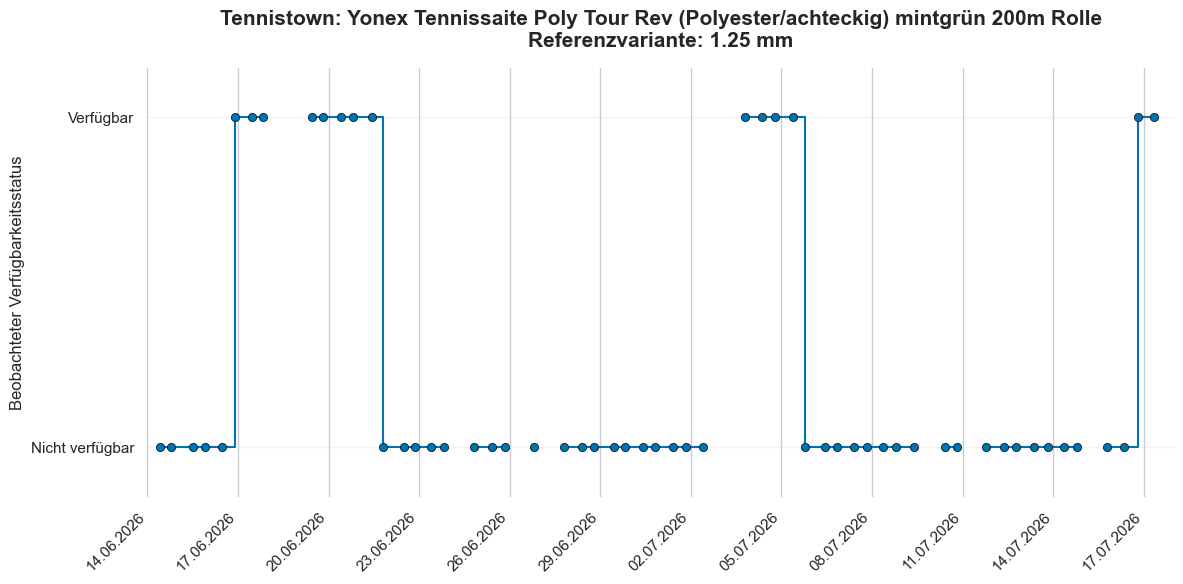

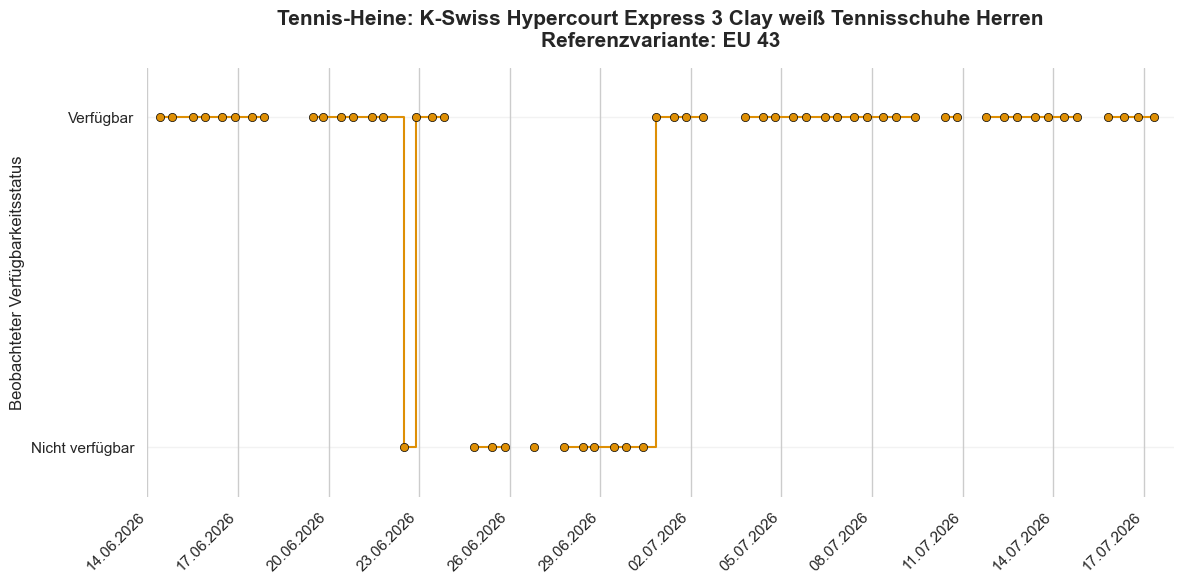

In [14]:
# --- VERFÜGBARKEITSVERLÄUFE DER AUSGEWÄHLTEN PRODUKTVARIANTEN VISUALISIEREN ---

# Einheitliche Farben für die beiden Händler festlegen
retailer_colors = dict(zip(retailer_order, sns.color_palette('colorblind', n_colors=len(retailer_order))))

# Ersten und letzten Kalendertag des Erhebungszeitraums bestimmen
availability_start_date = df_availability_data['run_date'].min()
availability_end_date = df_availability_data['run_date'].max()

# Datumsmarkierungen im Abstand von drei Tagen ab dem ersten Erhebungstag erzeugen
availability_tick_positions = pd.date_range(start=availability_start_date, end=availability_end_date, freq='3D').tolist()

# Letzten Erhebungstag zusätzlich anzeigen
if availability_tick_positions[-1] != availability_end_date:
    availability_tick_positions.append(availability_end_date)

# Datumsmarkierungen für die Achse formatieren
availability_tick_labels = [timestamp.strftime('%d.%m.%Y') for timestamp in availability_tick_positions]

# Für jede ausgewählte Produktvariante eine separate Abbildung erzeugen
for _, selected_variant in df_selected_availability_variants.iterrows():
    retailer = selected_variant['retailer']
    product_url_key = selected_variant['product_url_key']
    reference_variant = selected_variant['reference_variant']
    product_name = selected_variant['Name']

    # Vollständige Beobachtungshistorie der aktuellen Produktvariante auswählen
    df_case_history = df_selected_availability_history.loc[
        df_selected_availability_history['retailer'].eq(retailer)
        & df_selected_availability_history['product_url_key'].eq(product_url_key)
        & df_selected_availability_history['reference_variant'].eq(reference_variant)
    ]

    # Separate Diagrammfläche für die aktuelle Produktvariante vorbereiten
    fig, ax = plt.subplots(figsize=(12, 6))

    # Zusammenhängende Beobachtungsabschnitte getrennt durchlaufen
    for _, df_line_segment in df_case_history.groupby('availability_segment', sort=False):

        # Verfügbarkeitsstatus innerhalb des zusammenhängenden Abschnitts stufenförmig darstellen
        ax.step(
            df_line_segment['timestamp'],
            df_line_segment['availability_value'],
            where='post',
            color=retailer_colors[retailer],
            linewidth=1.5
        )

        # Tatsächlich vorhandene Produktbeobachtungen als Punkte kennzeichnen
        ax.scatter(
            df_line_segment['timestamp'],
            df_line_segment['availability_value'],
            color=retailer_colors[retailer],
            s=35,
            edgecolor='black',
            linewidth=0.5,
            zorder=3
        )

    # Diagramm beschriften
    ax.set_title(f'{retailer}: {product_name}\nReferenzvariante: {reference_variant}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Beobachteter Verfügbarkeitsstatus')

    # Numerische Positionen mit den ursprünglichen Verfügbarkeitszuständen beschriften
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Nicht verfügbar', 'Verfügbar'])
    ax.set_ylim(-0.15, 1.15)

    # Einheitliche Datumsmarkierungen für beide Fallbeispiele verwenden
    ax.set_xticks(availability_tick_positions)
    ax.set_xticklabels(availability_tick_labels, rotation=45, ha='right')

    # Achse vom Beginn des ersten bis zum Ende des letzten Erhebungstages darstellen
    ax.set_xlim(availability_start_date, availability_end_date + pd.Timedelta(days=1))

    # Gitternetz anpassen
    ax.grid(axis='y', alpha=0.25)

    # Diagramm abschließend formatieren und anzeigen
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()
    plt.show()

Die ausgewählte Tennistown-Produktvariante weist vier unmittelbar beobachtete Verfügbarkeitswechsel auf. Dabei treten jeweils zwei Wechsel von `in_stock` zu `out_of_stock` und von `out_of_stock` zu `in_stock` auf. Zusätzlich unterscheidet sich der Status vor und nach einer Erfassungslücke Anfang Juli. Innerhalb dieser Lücke muss daher mindestens ein weiterer, zeitlich nicht genauer bestimmbarer Wechsel stattgefunden haben. Insgesamt lassen sich somit mindestens fünf Verfügbarkeitswechsel ableiten.

Bei der ausgewählten Tennis-Heine-Produktvariante werden drei unmittelbar beobachtete Wechsel festgestellt, davon einer zur Nichtverfügbarkeit und zwei zurück zur Verfügbarkeit. Auch hier unterscheiden sich die Zustände vor und nach einer Erfassungslücke, sodass mindestens ein weiterer unbeobachteter Wechsel stattgefunden haben muss. Für diese Produktvariante sind daher insgesamt mindestens vier Verfügbarkeitswechsel anzunehmen.

Die Fallbeispiele zeigen, dass die auf unmittelbar vergleichbaren Beobachtungspaaren beruhende Auswertung nur sicher beobachtbare Wechsel erfasst. Bei unterschiedlichen Zuständen vor und nach einer Erfassungslücke kann zwar mindestens ein zusätzlicher Wechsel abgeleitet werden, dessen genauer Zeitpunkt und mögliche weitere Wechsel innerhalb der Lücke bleiben jedoch unbekannt.

Da gezielt Varianten mit besonders vielen beobachteten Wechseln ausgewählt wurden, sind die dargestellten Verläufe nicht repräsentativ für das gesamte Sortiment der jeweiligen Händler.

## Explorative Wimbledon-Fallbetrachtung

Abschließend wird explorativ untersucht, ob sich bei ausgewählten Schlägermodellen im zeitlichen Umfeld von Wimbledon Auffälligkeiten im beobachteten Verfügbarkeitsstatus zeigen. Wimbledon 2026 fand vom 29.06. bis zum 12.07.2026 statt und liegt damit vollständig innerhalb des Erhebungszeitraums vom 14.06. bis zum 17.07.2026. Dadurch stehen grundsätzlich Beobachtungen vor, während und nach dem Turnier zur Verfügung.

Betrachtet werden die öffentlich zugeordneten Schlägermodelle der vier Halbfinalisten des Herren-Einzels 2026:

- Jannik Sinner: HEAD Speed MP 2026
- Novak Djokovic: HEAD Speed Pro Legend 2025
- Alexander Zverev: HEAD Gravity Pro 2025
- Arthur Fery: Wilson Defyer 98 Pro (während Wimbledon als schwarz lackierter Vorserien- beziehungsweise Prototypenrahmen)

> **Quellenhinweis:** Der Turnierzeitraum und die Halbfinalisten wurden anhand der offiziellen [Wimbledon-Terminübersicht](https://www.wimbledon.com/en_GB/scores/schedule/schedule3.html) und der veröffentlichten Halbfinalbegegnungen geprüft. Die Modellzuordnungen beruhen auf den Herstellerangaben von [HEAD zum Speed MP](https://www.head.com/en_US/product/speed-mp-2026-232026), zur [Speed-Legend-Serie](https://www.head.com/en_US/sports/tennis/speed-legend), zum [Gravity Pro](https://www.head.com/en/product/gravity-pro-2025-231105) sowie von [Wilson zum Defyer](https://www.wilson.com/de-de/blog/tennis/introducing-wilson-defyer-tennis-racket).
>
> Arthur Fery spielte während Wimbledon mit einem schwarz lackierten Vorserienrahmen aus der Defyer-Entwicklung. [Forbes berichtete während des Turniers über diesen „blacked-out Defyer“](https://www.forbes.com/sites/timnewcomb/2026/07/09/tour-players-lead-new-wilson-defyer-racket-design/). Die Zuordnung zum Defyer 98 Pro bezeichnet daher das zugehörige spätere Handelsmodell und belegt keine vollständige technische Übereinstimmung mit Ferys individuellem Turnierschläger.

Die entsprechenden Händlerprodukte wurden manuell anhand der Produktseiten überprüft und anschließend über den jeweiligen `product_url_key` im aufbereiteten Datenbestand identifiziert. Sämtliche vorhandenen Referenzvarianten L2 und L3 werden berücksichtigt, da sich deren Verfügbarkeitszustände unterscheiden können. Eine normalisierte GTIN ist für diese händlerinterne Betrachtung nicht erforderlich. Dadurch kann auch die bei Tennistown vorhandene Variante L3 des Gravity Pro einbezogen werden, obwohl für sie keine `gtin_normalized` vorliegt.

Bevor die Verfügbarkeit vor, während und nach Wimbledon verglichen wird, wird zunächst kontrolliert, bei welchen Händlern und über welchen Zeitraum die zugeordneten Produkte tatsächlich im historischen Datenbestand beobachtet wurden.

In [15]:
# --- WIMBLEDON-HALBFINALISTEN UND ZUGEORDNETE HÄNDLERPRODUKTE FESTLEGEN ---

# Reihenfolge der betrachteten Spieler festlegen
player_order = ['Jannik Sinner', 'Novak Djokovic', 'Alexander Zverev', 'Arthur Fery']

# Manuell geprüfte Zuordnung der Spieler zu den Händlerprodukten dokumentieren
df_wimbledon_product_mapping = pd.DataFrame([
    {'player': 'Jannik Sinner', 'associated_brand': 'Head', 'associated_model': 'Speed MP 2026', 'retailer': 'Tennistown', 'product_url_key': '100159'},
    {'player': 'Jannik Sinner', 'associated_brand': 'Head', 'associated_model': 'Speed MP 2026', 'retailer': 'Tennis-Heine', 'product_url_key': '/head-speed-mp-2026-tennisschlaeger-4995'},
    {'player': 'Novak Djokovic', 'associated_brand': 'Head', 'associated_model': 'Speed Pro Legend 2025', 'retailer': 'Tennistown', 'product_url_key': '95871'},
    {'player': 'Novak Djokovic', 'associated_brand': 'Head', 'associated_model': 'Speed Pro Legend 2025', 'retailer': 'Tennis-Heine', 'product_url_key': '/head-speed-pro-legend-2025-tennisschlaeger-4865'},
    {'player': 'Alexander Zverev', 'associated_brand': 'Head', 'associated_model': 'Gravity Pro 2025', 'retailer': 'Tennistown', 'product_url_key': '88906'},
    {'player': 'Alexander Zverev', 'associated_brand': 'Head', 'associated_model': 'Gravity Pro 2025', 'retailer': 'Tennis-Heine', 'product_url_key': '/head-gravity-pro-2025-tennisschlaeger-4476'},
    {'player': 'Arthur Fery', 'associated_brand': 'Wilson', 'associated_model': 'Defyer 98 Pro', 'retailer': 'Tennistown', 'product_url_key': pd.NA},
    {'player': 'Arthur Fery', 'associated_brand': 'Wilson', 'associated_model': 'Defyer 98 Pro', 'retailer': 'Tennis-Heine', 'product_url_key': '/detail/index/sArticle/5286/sCategory/12'}
])

# URL-Produktschlüssel als Zeichenfolge speichern
df_wimbledon_product_mapping['product_url_key'] = df_wimbledon_product_mapping['product_url_key'].astype('string')

# --- BEOBACHTUNGEN DER ZUGEORDNETEN HÄNDLERPRODUKTE AUSWÄHLEN ---

# Vorhandene Händlerprodukte über Händler und URL-Produktschlüssel mit dem Datenbestand verbinden
df_wimbledon_availability_data = df_availability_data.merge(
    df_wimbledon_product_mapping.dropna(subset=['product_url_key']),
    on=['retailer', 'product_url_key'],
    how='inner',
    validate='many_to_one'
)

# --- BEOBACHTUNGSUMFANG DER ZUGEORDNETEN PRODUKTE ZUSAMMENFASSEN ---
df_wimbledon_observed_coverage = (
    df_wimbledon_availability_data
    .groupby(['player', 'associated_brand', 'associated_model', 'retailer'], sort=False)
    .agg(
        Product_name=('name', 'last'),                                        # Zuletzt erfassten Produktnamen übernehmen
        Product_variants=('reference_variant', 'nunique'),                    # Anzahl vorhandener Referenzvarianten bestimmen
        Observations=('availability', 'size'),                                # Vorhandene Produktbeobachtungen zählen
        First_observation=('run_date', 'min'),                                # Ersten Beobachtungstag bestimmen
        Last_observation=('run_date', 'max'),                                 # Letzten Beobachtungstag bestimmen
        In_stock=('availability', lambda values: values.eq('in_stock').sum()),
        Out_of_stock=('availability', lambda values: values.eq('out_of_stock').sum())
    )
    .reset_index()
)

# Kontrolltabelle um Händler ohne zugeordnetes Produkt ergänzen
df_wimbledon_product_coverage_overview = (
    df_wimbledon_product_mapping[['player', 'associated_brand', 'associated_model', 'retailer']]
    .merge(
        df_wimbledon_observed_coverage,
        on=['player', 'associated_brand', 'associated_model', 'retailer'],
        how='left',
        validate='one_to_one'
    )
)

# Fehlende Anzahlen bei nicht vorhandenen Händlerprodukten als null ausweisen
count_columns = ['Product_variants', 'Observations', 'In_stock', 'Out_of_stock']

df_wimbledon_product_coverage_overview[count_columns] = (
    df_wimbledon_product_coverage_overview[count_columns]
    .fillna(0)
    .astype(int)
)

# Spaltenbezeichnungen für die Ausgabe vereinheitlichen
df_wimbledon_product_coverage_overview = df_wimbledon_product_coverage_overview.rename(columns={
    'player': 'Player',
    'associated_brand': 'Brand',
    'associated_model': 'Associated model',
    'retailer': 'Retailer',
    'Product_name': 'Product name',
    'Product_variants': 'Product variants',
    'First_observation': 'First observation',
    'Last_observation': 'Last observation',
    'In_stock': 'In stock',
    'Out_of_stock': 'Out of stock'
})

# Spieler und Händler in der festgelegten Reihenfolge anordnen
df_wimbledon_product_coverage_overview['Player'] = pd.Categorical(
    df_wimbledon_product_coverage_overview['Player'],
    categories=player_order,
    ordered=True
)

df_wimbledon_product_coverage_overview['Retailer'] = pd.Categorical(
    df_wimbledon_product_coverage_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_wimbledon_product_coverage_overview = (
    df_wimbledon_product_coverage_overview
    .sort_values(['Player', 'Retailer'])
    .reset_index(drop=True)
)

print('--- DATENABDECKUNG DER WIMBLEDON-BEZOGENEN SCHLÄGERMODELLE ---')
print('Zeigt vorhandene Produktvarianten und den Beobachtungszeitraum der manuell zugeordneten Händlerprodukte.\n')

display(df_wimbledon_product_coverage_overview)

--- DATENABDECKUNG DER WIMBLEDON-BEZOGENEN SCHLÄGERMODELLE ---
Zeigt vorhandene Produktvarianten und den Beobachtungszeitraum der manuell zugeordneten Händlerprodukte.



,Player,Brand,Associated model,Retailer,Product name,Product variants,Observations,First observation,Last observation,In stock,Out of stock
0,Jannik Sinner,Head,Speed MP 2026,Tennistown,Head Tennisschläger Speed MP 100in/300g/Turnie...,2,114,2026-06-14,2026-07-17,84,30
1,Jannik Sinner,Head,Speed MP 2026,Tennis-Heine,Head Speed MP 2026 Tennisschläger,2,114,2026-06-14,2026-07-17,114,0
2,Novak Djokovic,Head,Speed Pro Legend 2025,Tennistown,Head Tennisschläger Speed Pro Legend 100in/310...,2,114,2026-06-14,2026-07-17,112,2
3,Novak Djokovic,Head,Speed Pro Legend 2025,Tennis-Heine,Head Speed Pro Legend 2025 Tennisschläger,2,114,2026-06-14,2026-07-17,77,37
4,Alexander Zverev,Head,Gravity Pro 2025,Tennistown,Head Tennisschläger Gravity Pro 100in/315g/Tur...,2,114,2026-06-14,2026-07-17,57,57
5,Alexander Zverev,Head,Gravity Pro 2025,Tennis-Heine,Head Gravity Pro 2025 Tennisschläger,2,114,2026-06-14,2026-07-17,0,114
6,Arthur Fery,Wilson,Defyer 98 Pro,Tennistown,NaN,0,0,NaT,NaT,0,0
7,Arthur Fery,Wilson,Defyer 98 Pro,Tennis-Heine,Wilson Defyer 98 Pro Tennisschläger,2,4,2026-07-16,2026-07-17,4,0


Für die Sinner, Djokovic und Zverev zugeordneten Schlägermodelle liegen bei Tennistown und Tennis-Heine in allen drei Untersuchungszeiträumen Beobachtungen für L2 und L3 vor. Für diese Modelle ist daher grundsätzlich eine explorative Gegenüberstellung der Verfügbarkeit vor, während und nach Wimbledon möglich.

Der Arthur Fery zugeordnete Wilson Defyer 98 Pro wird erst während der Markteinführungsphase bei Tennis-Heine beobachtet und ist bei Tennistown nicht im Datenbestand enthalten. Die fehlenden früheren Beobachtungen werden daher nicht als Nichtverfügbarkeit interpretiert und das Modell wird nicht in den anschließenden Periodenvergleich einbezogen.

### Verfügbarkeit vor, während und nach Wimbledon vergleichen

Für die bereits vor Turnierbeginn beobachteten Schlägermodelle wird die Verfügbarkeit in drei Zeiträume unterteilt:

- vor Wimbledon: 14.06. bis 28.06.2026
- während Wimbledon: 29.06. bis 12.07.2026
- nach Wimbledon: 13.07. bis 17.07.2026

Für jede Kombination aus Spieler, Händler und Referenzvariante wird berechnet, bei welchem Anteil der vorhandenen Produktbeobachtungen der Status `in_stock` vorliegt. Ein Wert von 100 % bedeutet, dass die Variante in sämtlichen vorhandenen Beobachtungen des jeweiligen Zeitraums verfügbar war. Bei 0 % wurde sie in keiner Beobachtung als verfügbar erfasst.

Die Auswertung erfolgt getrennt nach den Referenzvarianten L2 und L3, da sich deren Verfügbarkeitsverläufe unterscheiden können. Arthur Fery wird nicht in den Periodenvergleich einbezogen, weil das zugeordnete Schlägermodell erst nach Wimbledon im Datenbestand erscheint.

Die drei Zeiträume sind unterschiedlich lang. Insbesondere der Zeitraum nach Wimbledon umfasst lediglich fünf Tage. Die Ergebnisse werden deshalb ausschließlich deskriptiv interpretiert.

In [16]:
# --- BEOBACHTUNGEN DEN WIMBLEDON-ZEITRÄUMEN ZUORDNEN ---

# Beginn und Ende von Wimbledon 2026 festlegen
wimbledon_start_date = pd.Timestamp('2026-06-29')
wimbledon_end_date = pd.Timestamp('2026-07-12')

# Englische Bezeichnungen und Reihenfolge der Untersuchungszeiträume festlegen
wimbledon_period_order = ['Before Wimbledon', 'During Wimbledon', 'After Wimbledon']

# Arthur Fery wegen der fehlenden Beobachtungen vor und während Wimbledon ausschließen
df_wimbledon_period_data = (
    df_wimbledon_availability_data
    .loc[df_wimbledon_availability_data['player'].ne('Arthur Fery')]
    .copy()
)

# Beobachtungen zunächst dem Zeitraum nach Wimbledon zuordnen
df_wimbledon_period_data['wimbledon_period'] = 'After Wimbledon'

# Beobachtungen vor Wimbledon kennzeichnen
df_wimbledon_period_data.loc[df_wimbledon_period_data['run_date'].lt(wimbledon_start_date), 'wimbledon_period'] = 'Before Wimbledon'

# Beobachtungen während Wimbledon kennzeichnen
df_wimbledon_period_data.loc[df_wimbledon_period_data['run_date'].between(wimbledon_start_date, wimbledon_end_date), 'wimbledon_period'] = 'During Wimbledon'

# Zeiträume als geordnete Kategorien speichern
df_wimbledon_period_data['wimbledon_period'] = pd.Categorical(
    df_wimbledon_period_data['wimbledon_period'],
    categories=wimbledon_period_order,
    ordered=True
)

# --- VERFÜGBARKEITSANTEILE INNERHALB DER ZEITRÄUME BERECHNEN ---
df_wimbledon_period_summary = (
    df_wimbledon_period_data
    .groupby(['player', 'associated_model', 'retailer', 'reference_variant', 'wimbledon_period'], sort=False, observed=True)
    .agg(In_stock_rate_pct=('availability', lambda values: values.eq('in_stock').mean() * 100)) 
    .reset_index()
)

# Prozentwerte auf zwei Nachkommastellen runden
df_wimbledon_period_summary['In_stock_rate_pct'] = df_wimbledon_period_summary['In_stock_rate_pct'].round(2)

# --- ZEITRÄUME IN DER ERGEBNISTABELLE NEBENEINANDER ANORDNEN ---
df_wimbledon_period_overview = (
    df_wimbledon_period_summary
    .pivot(
        index=['player', 'associated_model', 'retailer', 'reference_variant'],
        columns='wimbledon_period',
        values='In_stock_rate_pct'
    )
    .reset_index()
    .rename(columns={
        'player': 'Player',
        'associated_model': 'Associated model',
        'retailer': 'Retailer',
        'reference_variant': 'Reference variant',
        'Before Wimbledon': 'Before Wimbledon in stock (%)',
        'During Wimbledon': 'During Wimbledon in stock (%)',
        'After Wimbledon': 'After Wimbledon in stock (%)'
    })
)

# Bezeichnung der Spaltenachse entfernen
df_wimbledon_period_overview.columns.name = None

# Spieler und Händler in der festgelegten Reihenfolge anordnen
df_wimbledon_period_overview['Player'] = pd.Categorical(
    df_wimbledon_period_overview['Player'],
    categories=player_order,
    ordered=True
)

df_wimbledon_period_overview['Retailer'] = pd.Categorical(
    df_wimbledon_period_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_wimbledon_period_overview = (
    df_wimbledon_period_overview
    .sort_values(['Player', 'Retailer', 'Reference variant'])
    .reset_index(drop=True)
)

print('--- VERFÜGBARKEIT VOR, WÄHREND UND NACH WIMBLEDON ---')
print('Zeigt den Anteil verfügbarer Beobachtungen je Spieler, Händler, Referenzvariante und Zeitraum.\n')

display(df_wimbledon_period_overview)

--- VERFÜGBARKEIT VOR, WÄHREND UND NACH WIMBLEDON ---
Zeigt den Anteil verfügbarer Beobachtungen je Spieler, Händler, Referenzvariante und Zeitraum.



,Player,Associated model,Retailer,Reference variant,Before Wimbledon in stock (%),During Wimbledon in stock (%),After Wimbledon in stock (%)
0,Jannik Sinner,Speed MP 2026,Tennistown,L2,92.0,58.33,100.0
1,Jannik Sinner,Speed MP 2026,Tennistown,L3,88.0,41.67,87.5
2,Jannik Sinner,Speed MP 2026,Tennis-Heine,L2,100.0,100.00,100.0
3,Jannik Sinner,Speed MP 2026,Tennis-Heine,L3,100.0,100.00,100.0
4,Novak Djokovic,Speed Pro Legend 2025,Tennistown,L2,92.0,100.00,100.0
5,Novak Djokovic,Speed Pro Legend 2025,Tennistown,L3,100.0,100.00,100.0
6,Novak Djokovic,Speed Pro Legend 2025,Tennis-Heine,L2,100.0,100.00,100.0
7,Novak Djokovic,Speed Pro Legend 2025,Tennis-Heine,L3,80.0,0.00,0.0
8,Alexander Zverev,Gravity Pro 2025,Tennistown,L2,100.0,100.00,100.0
9,Alexander Zverev,Gravity Pro 2025,Tennistown,L3,0.0,0.00,0.0


Beim Jannik Sinner zugeordneten Speed MP zeigt sich bei Tennis-Heine keine Veränderung: Sowohl L2 als auch L3 sind vor, während und nach Wimbledon in sämtlichen vorhandenen Beobachtungen verfügbar. Bei Tennistown fällt der Verfügbarkeitsanteil dagegen während des Turniers deutlich. Für L2 sinkt er von 92,00 % vor Wimbledon auf 58,33 % während des Turniers und steigt anschließend auf 100,00 %. Bei L3 geht der Anteil von 88,00 % auf 41,67 % zurück und erreicht nach Wimbledon wieder 87,50 %.

Beim Novak Djokovic zugeordneten Speed Pro Legend bleibt die Verfügbarkeit bei Tennistown weitgehend konstant. Bei Tennis-Heine ist L2 ebenfalls durchgängig verfügbar. Die Variante L3 weist dagegen vor Wimbledon noch einen Verfügbarkeitsanteil von 80,00 % auf, ist während und nach dem Turnier jedoch in keiner vorhandenen Beobachtung verfügbar.

Beim Alexander Zverev zugeordneten Gravity Pro treten keine Veränderungen zwischen den drei Zeiträumen auf. Bei Tennistown ist L2 durchgängig verfügbar und L3 durchgängig nicht verfügbar. Bei Tennis-Heine sind beide betrachteten Referenzvarianten über den gesamten Erhebungszeitraum nicht verfügbar.

Besonders auffällig ist damit der Verfügbarkeitsverlauf des Jannik Sinner zugeordneten Speed MP bei Tennistown. Sowohl L2 als auch L3 weisen während Wimbledon einen deutlich geringeren Verfügbarkeitsanteil als vor dem Turnier auf und sind danach wieder häufiger verfügbar. Dieser Verlauf wird im folgenden Abschnitt genauer dargestellt.

Die Variante L3 des Novak Djokovic zugeordneten Speed Pro Legend bei Tennis-Heine wird nicht als Fallbeispiel visualisiert. Sie ist bereits vor Wimbledon nicht mehr durchgängig verfügbar und weist während sowie nach dem Turnier einen Verfügbarkeitsanteil von 0 % auf. Ein möglicher weiterer Rückgang der Verfügbarkeit während des Turniers kann daher nicht untersucht werden.

Die zeitliche Übereinstimmung zwischen Wimbledon und der geringeren Verfügbarkeit des Speed MP ist ausschließlich als explorative Auffälligkeit zu verstehen.

### Verfügbarkeitsverläufe des Speed MP bei Tennistown betrachten

Zur zeitlichen Einordnung werden die Verfügbarkeitsverläufe des Jannik Sinner zugeordneten Speed MP bei Tennistown dargestellt. Für die Referenzvarianten L2 und L3 wird jeweils eine separate Abbildung erzeugt, damit sich die Verläufe nicht gegenseitig überdecken.

Der Zeitraum von Wimbledon wird in beiden Diagrammen farblich hervorgehoben. Die Linien verbinden ausschließlich unmittelbar aufeinanderfolgende Produktbeobachtungen. Bei Erfassungslücken wird die Verbindung unterbrochen, damit fehlende Beobachtungen nicht als unveränderter Verfügbarkeitsstatus dargestellt werden.

In [17]:
# --- VERFÜGBARKEITSVERLAUF DES SPEED MP VORBEREITEN ---

# Wimbledon-Zuordnungen mit der chronologisch vorbereiteten Beobachtungshistorie verbinden
df_wimbledon_case_history = df_availability_history.merge(
    df_wimbledon_product_mapping.dropna(subset=['product_url_key']),
    on=['retailer', 'product_url_key'],
    how='inner',
    validate='many_to_one'
)

# Speed MP bei Tennistown in den Referenzvarianten L2 und L3 auswählen
df_sinner_speed_mp_history = (
    df_wimbledon_case_history
    .loc[
        df_wimbledon_case_history['player'].eq('Jannik Sinner')
        & df_wimbledon_case_history['retailer'].eq('Tennistown')
        & df_wimbledon_case_history['reference_variant'].isin(['L2', 'L3'])
    ]
    .copy()
)

# Nach der ersten Beobachtung und nach jeder Erfassungslücke ein neues Liniensegment beginnen
df_sinner_speed_mp_history['availability_segment'] = (
    df_sinner_speed_mp_history
    .groupby('reference_variant', sort=False)['comparison_interval']
    .transform(lambda values: values.isna().cumsum())
)

# Verfügbarkeitszustände für die vertikale Position im Diagramm numerisch abbilden
df_sinner_speed_mp_history['availability_value'] = (
    df_sinner_speed_mp_history['availability']
    .map({'out_of_stock': 0, 'in_stock': 1})
)

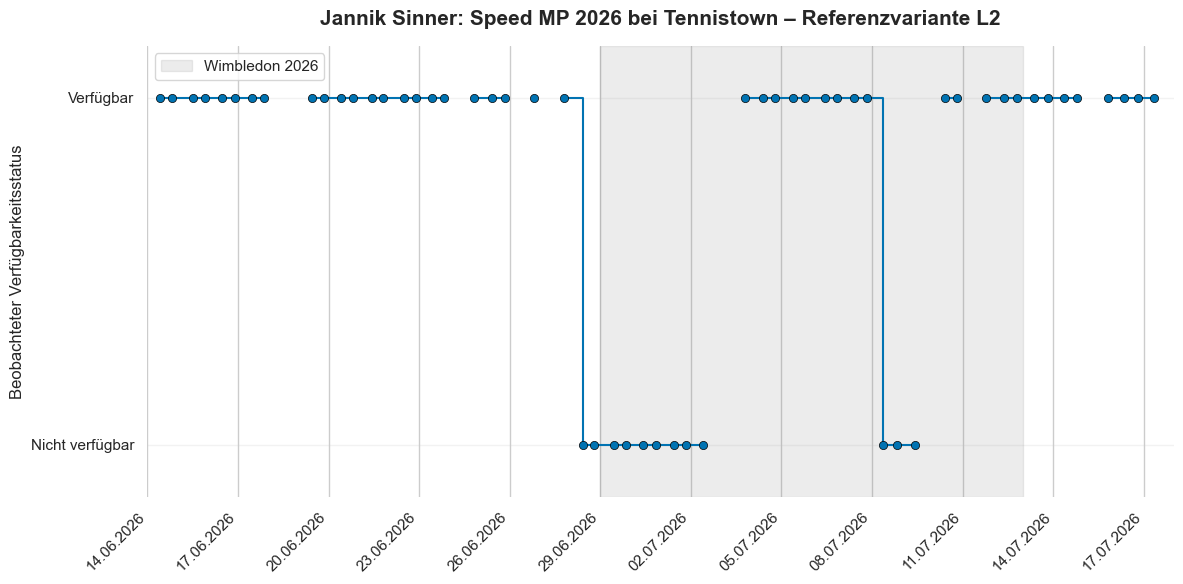

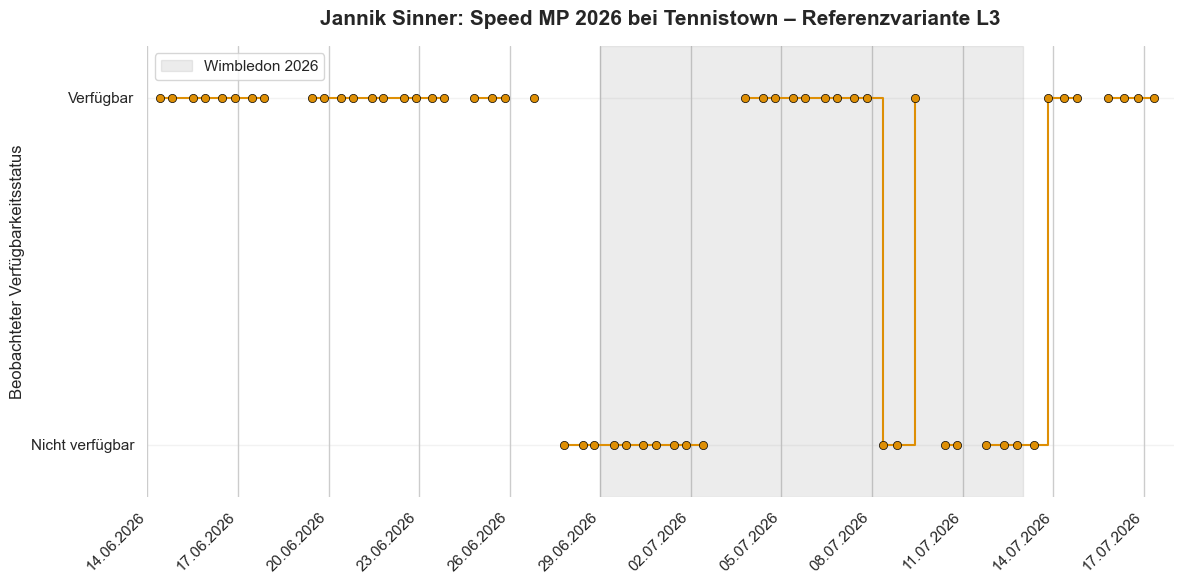

In [18]:
# --- VERFÜGBARKEITSVERLÄUFE DES SPEED MP VISUALISIEREN ---

# Reihenfolge und Farben der Referenzvarianten festlegen
variant_order = ['L2', 'L3']
variant_colors = dict(zip(variant_order, sns.color_palette('colorblind', n_colors=2)))

# Für jede Referenzvariante eine separate Abbildung erzeugen
for reference_variant in variant_order:

    # Beobachtungen der aktuellen Referenzvariante auswählen
    df_variant_history = df_sinner_speed_mp_history.loc[df_sinner_speed_mp_history['reference_variant'].eq(reference_variant)]

    # Separate Diagrammfläche vorbereiten
    fig, ax = plt.subplots(figsize=(12, 6))

    # Wimbledon-Zeitraum einschließlich des vollständigen letzten Turniertages hervorheben
    ax.axvspan(
        wimbledon_start_date,
        wimbledon_end_date + pd.Timedelta(days=1),
        color='grey',
        alpha=0.15,
        label='Wimbledon 2026'
    )

    # Zusammenhängende Beobachtungsabschnitte getrennt darstellen
    for _, df_line_segment in df_variant_history.groupby('availability_segment', sort=False):

        # Verfügbarkeitsstatus stufenförmig darstellen
        ax.step(
            df_line_segment['timestamp'],
            df_line_segment['availability_value'],
            where='post',
            color=variant_colors[reference_variant],
            linewidth=1.5
        )

        # Tatsächlich vorhandene Beobachtungen als Punkte kennzeichnen
        ax.scatter(
            df_line_segment['timestamp'],
            df_line_segment['availability_value'],
            color=variant_colors[reference_variant],
            s=35,
            edgecolor='black',
            linewidth=0.5,
            zorder=3
        )

    # Diagramm beschriften
    ax.set_title(f'Jannik Sinner: Speed MP 2026 bei Tennistown – Referenzvariante {reference_variant}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Beobachteter Verfügbarkeitsstatus')

    # Verfügbarkeitszustände auf der y-Achse beschriften
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Nicht verfügbar', 'Verfügbar'])
    ax.set_ylim(-0.15, 1.15)

    # Einheitliche Datumsmarkierungen verwenden
    ax.set_xticks(availability_tick_positions)
    ax.set_xticklabels(availability_tick_labels, rotation=45, ha='right')
    ax.set_xlim(availability_start_date, availability_end_date + pd.Timedelta(days=1))

    # Legende und Gitternetz anpassen
    ax.legend()
    ax.grid(axis='y', alpha=0.25)

    # Diagramm abschließend formatieren und anzeigen
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()
    plt.show()

Die Verfügbarkeitsverläufe des Speed MP bei Tennistown weisen im Vergleich zum übrigen Datenbestand eine deutliche Auffälligkeit auf. Insgesamt werden bei Tennistown nur bei 0,27 % der unmittelbar vergleichbaren Beobachtungspaare Verfügbarkeitswechsel festgestellt. Zudem ist lediglich ein kleiner Teil der Produktvarianten überhaupt von solchen Wechseln betroffen.

Beim Speed MP lassen sich dagegen für L2 mindestens vier und für L3 mindestens sechs Verfügbarkeitswechsel erkennen. Bei L2 werden zwei Wechsel unmittelbar zwischen aufeinanderfolgenden Abrufen beobachtet. Zwei weitere werden daraus abgeleitet, dass sich der Verfügbarkeitsstatus vor und nach einer Erfassungslücke unterscheidet. Bei L3 werden drei Wechsel unmittelbar beobachtet und mindestens drei weitere anhand unterschiedlicher Zustände vor und nach Erfassungslücken abgeleitet.

Nach einer längeren stabilen Verfügbarkeit wird die erste Nichtverfügbarkeit bei L2 am 28.06. und bei L3 am 27.06. erstmals beobachtet. Sämtliche mindestens vier Wechsel von L2 liegen unmittelbar vor oder während Wimbledon. Bei L3 konzentrieren sich fünf der mindestens sechs erkennbaren Wechsel ebenfalls auf diesen Zeitraum. Der letzte Wechsel von L3 wird am 13.07. und damit am ersten Tag nach Wimbledon beobachtet. Gleichzeitig fällt der Verfügbarkeitsanteil während des Turniers bei L2 auf 58,33 % und bei L3 auf 41,67 %. Nach Wimbledon steigt er wieder auf 100,00 % beziehungsweise 87,50 %.

Die Konzentration der Verfügbarkeitswechsel im zeitlichen Umfeld des Turniers und das ähnliche Muster beider Referenzvarianten sprechen für einen möglichen Zusammenhang mit Wimbledon. Eine plausible Erklärung ist, dass die erhöhte Aufmerksamkeit für Jannik Sinner und das ihm zugeordnete Schlägermodell die Nachfrage bei Tennistown beeinflusst hat. Der Verlauf liefert damit einen deutlichen deskriptiven Hinweis auf einen möglichen Wimbledon-Effekt.

Ein eindeutiger kausaler Nachweis ist dennoch nicht möglich. Die erste Nichtverfügbarkeit beginnt bereits kurz vor Turnierbeginn, während das Modell bei Tennis-Heine durchgängig verfügbar bleibt. Zudem liegen keine Verkaufszahlen, Lagerbestandsmengen oder Informationen über Nachlieferungen vor. Der beobachtete Zusammenhang ist daher als begründete, aber nicht abschließend beweisbare Interpretation einzuordnen.